In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import matplotlib.dates as mdates


# Set global font size using rcParams
plt.rcParams.update({
    'font.size': 18,  # General font size
    'axes.titlesize': 20,  # Title font size
    'axes.labelsize': 18,  # Axis label font size
    'xtick.labelsize': 16,  # X-axis tick label size
    'ytick.labelsize': 16,  # Y-axis tick label size
    'legend.fontsize': 16,  # Legend font size
    'figure.titlesize': 22  # Overall figure title size (if used)
})


<jemalloc>: MADV_DONTNEED does not work (memset will be used instead)
<jemalloc>: (This is the expected behaviour if you are running under QEMU)


In [4]:
df = pd.read_csv("/workspaces/CUBES/exp/jack/paper/thermostat_experiment/SI/fixed_occ_check/files/Eplus-env-11-09_thermostat_rbc_eco_year_2023_case_0_rep_H28_zone_0_inactive_threshold_30_comforttemp_20.0_setbacktemp_16.0_pattern_twice_timesteps_60_longer_heating_check_v3-res1_condensed.csv.xz", parse_dates=["UTC_Time"])

In [7]:
df = df.set_index("UTC_Time", drop=True)

In [71]:
march = df.loc["2013-03-21 00:00:00" :"2013-03-22 00:00:00" ]

# Filter for data between 23:00 and 06:00
march = march.between_time("15:55", "16:01")


<Axes: xlabel='UTC_Time'>

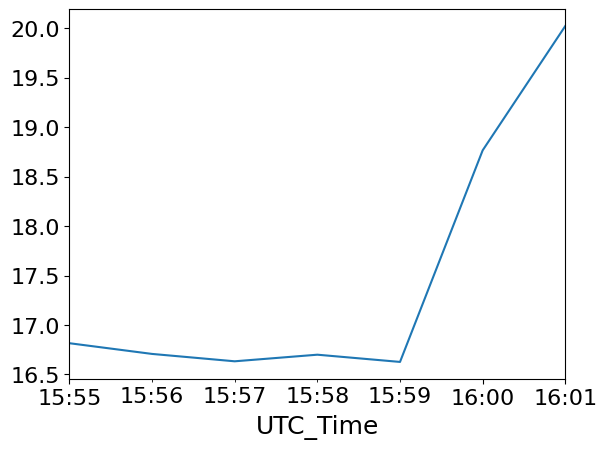

: 

In [ ]:
march["Zone Air Temperature(front_room)"].plot()

In [20]:
march["Zone People Occupant Count(kitchen)"].sum()

np.float64(0.0)

In [2]:

def load_emission_data(data_dir, emissions_col, date_col="UTC_Time"):
    cumulative_emissions = {}
    files = [f for f in os.listdir(data_dir) if f.endswith(".csv.xz")]

    for file in files:
        if ("zone_0" in file and "comforttemp_20.0" in file) or ("zone_9" in file and "11-12" in file):
            df = pd.read_csv(os.path.join(data_dir, file), usecols=[date_col, emissions_col], parse_dates=[date_col])
            df.set_index(date_col, inplace=True)
            daily_emissions = df[emissions_col].resample('D').sum().cumsum()

            zone = file.split("zone_")[-1].split("_")[0]
            comforttemp = file.split("comforttemp_")[-1].split("_")[0]
            threshold = file.split("threshold_")[-1].split("_")[0]
            label = f"Zone {zone}, Comfort {comforttemp}°C, Threshold {threshold}"

            cumulative_emissions[label] = daily_emissions

    return cumulative_emissions

def load_data(data_dir, date_col="UTC_Time"):
    cumulative_emissions = {}
    files = [f for f in os.listdir(data_dir) if f.endswith(".csv.xz")]

    for file in files:
        if ("zone_0" in file and "comforttemp_20.0" in file) or ("zone_9" in file and "11-09" in file):
            df = pd.read_csv(os.path.join(data_dir, file),  parse_dates=[date_col])
            df.set_index(date_col, inplace=True)

            zone = file.split("zone_")[-1].split("_")[0]
            comforttemp = file.split("comforttemp_")[-1].split("_")[0]
            threshold = file.split("threshold_")[-1].split("_")[0]
            label = f"Zone {zone}, Comfort {comforttemp}°C, Threshold {threshold}"

            cumulative_emissions[label] = df

    return cumulative_emissions


def plot_cumulative_emissions(cumulative_emissions):
    plt.figure(figsize=(16, 10))
    for label, daily_emissions in cumulative_emissions.items():
        plt.plot(daily_emissions.index, daily_emissions, label=label)

    plt.axvline(pd.Timestamp(f"{daily_emissions.index.year[0]}-04-01"), color='grey', linestyle='--', label='Start of April')
    plt.axvline(pd.Timestamp(f"{daily_emissions.index.year[0]}-10-01"), color='grey', linestyle='--', label='Start of October')

    plt.xlabel('Date')
    plt.ylabel('Cumulative CO2 Emissions (kg)')
    plt.title('Cumulative CO2 Emissions Throughout the Year')
    # plt.legend()
    plt.grid()
    plt.show()


def calculate_seasonal_emissions(cumulative_emissions):
    seasonal_totals = {}
    seasons = {
        'Jan-Apr': ('01-01', '04-01'),
        'Apr-Oct': ('04-01', '10-01'),
        'Oct-Jan': ('10-01', '01-01')
    }

    for label, daily_emissions in cumulative_emissions.items():
        seasonal_totals[label] = {}
        for season, (start, end) in seasons.items():
            if season == 'Oct-Jan':
                season_emissions = daily_emissions.loc[f"{daily_emissions.index.year[0]}-{start}":f"{daily_emissions.index.year[-1]+1}-{end}"]
            else:
                season_emissions = daily_emissions.loc[f"{daily_emissions.index.year[0]}-{start}":f"{daily_emissions.index.year[0]}-{end}"]
            seasonal_totals[label][season] = season_emissions.iloc[-1] - season_emissions.iloc[0]
    return seasonal_totals



room_areas = {
    'kitchen': 11.34,
    'front_room': 14.04,
    'backroom': 11.34,
    'hall_downstairs': 7.02,
    'bedroom_1': 11.51,
    'bedroom_2': 12.39,
    'bedroom_3': 6.86,
    'bathroom': 7.105,
    'hall_upstairs': 5.88,
}

# Define operative temperature columns for each zone
zones_short = [
    'kitchen',
    'front_room',
    'backroom',
    'hall_downstairs',
    'bedroom_1',
    'bedroom_2',
    'bedroom_3',
    'bathroom',
    'hall_upstairs',
]


def calculate_temp_diff(timed_df, not_timed_df, temp_type, zones, periods):
    room_diffs = {period: {} for period in periods}
    weighted_means = {}

    if temp_type == 'operative':
        temp_columns = {zone: f'Zone Operative Temperature({zone})' for zone in zones}
    elif temp_type == 'air':
        temp_columns = {zone: f'Zone Air Temperature({zone})' for zone in zones}
    else:
        raise ValueError("Invalid temperature type. Choose 'operative' or 'air'.")

    for period, (start, end) in periods.items():
        period_timed_df = timed_df[start:end]
        period_not_timed_df = not_timed_df[start:end]
        means = []

        for zone in zones:
            temp_column = temp_columns[zone]
            occupancy_column = f'Zone People Occupant Count({zone})'
            temp_diff = period_timed_df[temp_column] - period_not_timed_df[temp_column]
            temp_diff_occupied = temp_diff.where(period_timed_df[occupancy_column] > 0)

            mean_diff = temp_diff_occupied.mean()
            room_diffs[period][zone] = mean_diff
            means.append(mean_diff * room_areas[zone])

        weighted_means[period] = sum(means) / sum(room_areas.values())

    return weighted_means, room_diffs


def calculate_all_temp_diffs(data_dict, not_timed_df, temp_type, zones, periods):
    all_weighted_mean_diffs = {}
    all_room_diffs = {}

    for label, timed_df in data_dict.items():
        weighted_mean_diff, room_diffs = calculate_temp_diff(timed_df, not_timed_df, temp_type, zones, periods)
        all_weighted_mean_diffs[label] = weighted_mean_diff
        all_room_diffs[label] = room_diffs

    return all_weighted_mean_diffs, all_room_diffs


def calculate_emissions_reduction_and_temp_diff(data_dict, baseline_label, temp_type, zones, periods):
    baseline_df = data_dict[baseline_label]
    all_emissions_reductions = {}
    all_temp_diffs = {}

    # Calculate baseline cumulative emissions over each period and for the full year
    baseline_emissions = {}
    for period, (start, end) in periods.items():
        period_data = baseline_df[start:end]
        baseline_emissions[period] = period_data['Environmental Impact Total CO2 Emissions Carbon Equivalent Mass(Site)'].sum()

    # Add full-year emissions for baseline
    full_year_data = baseline_df[periods['Jan-Apr'][0]:periods['Oct-Jan'][1]]
    baseline_emissions['Full Year'] = full_year_data['Environmental Impact Total CO2 Emissions Carbon Equivalent Mass(Site)'].sum()

    # Calculate baseline temperature differences
    baseline_weighted_mean_diffs, _ = calculate_temp_diff(baseline_df, baseline_df, temp_type, zones, periods)

    # Calculate emissions reduction and temp difference for each zone compared to baseline
    for label, not_timed_df in data_dict.items():
        if label == baseline_label:
            continue  # Skip baseline as we only want comparisons

        # Calculate emissions reduction for each period and for the full year
        emissions_reduction = {}
        for period, (start, end) in periods.items():
            period_data = not_timed_df[start:end]
            emissions_sum = period_data['Environmental Impact Total CO2 Emissions Carbon Equivalent Mass(Site)'].sum()
            emissions_reduction[period] = 100 * ((baseline_emissions[period] - emissions_sum) / baseline_emissions[period])

        # Full-year emissions reduction
        full_year_data = not_timed_df[periods['Jan-Apr'][0]:periods['Oct-Jan'][1]]
        full_year_emissions_sum = full_year_data['Environmental Impact Total CO2 Emissions Carbon Equivalent Mass(Site)'].sum()
        emissions_reduction['Full Year'] = 100 * ((baseline_emissions['Full Year'] - full_year_emissions_sum) / baseline_emissions['Full Year'])

        # Calculate temperature difference from baseline for each period
        weighted_mean_diff, _ = calculate_temp_diff(baseline_df, not_timed_df, temp_type, zones, periods)
        temp_diff_from_baseline = {period: weighted_mean_diff[period] - baseline_weighted_mean_diffs[period] for period in periods}

        all_emissions_reductions[label] = emissions_reduction
        all_temp_diffs[label] = temp_diff_from_baseline

    return all_emissions_reductions, all_temp_diffs



def plot_temp_comparison(data_dict, baseline_label, comparison_label, temp_type):
    timed_jan_week = data_dict[baseline_label].loc['2013-01-22':'2013-01-29']
    not_timed_jan_week = data_dict[comparison_label].loc['2013-01-22':'2013-01-29']

    num_zones_to_show = 9
    means = []
    means_daytime = []  # To store the area-weighted mean differences for the daytime (06:00-23:00)

    if temp_type == 'operative':
        temp_columns = {zone: f'Zone Operative Temperature({zone})' for zone in room_areas.keys()}
        y_label = 'Temperature (°C)'
    elif temp_type == 'air':
        temp_columns = {zone: f'Zone Air Temperature({zone})' for zone in room_areas.keys()}
        y_label = 'Temperature (°C)'
    else:
        raise ValueError("Invalid temperature type. Choose 'operative' or 'air'.")

    fig, axes = plt.subplots(num_zones_to_show, 2, figsize=(14, 3 * num_zones_to_show), sharex=True)
    date_format = mdates.DateFormatter('%d/%m')

    if num_zones_to_show == 1:
        axes = [axes]

    global_diff_min, global_diff_max = float('inf'), float('-inf')
    global_temp_min, global_temp_max = float('inf'), float('-inf')

    # Filter data to include only hours between 06:00 and 23:00
    timed_jan_week_daytime = timed_jan_week.between_time("06:00", "23:00")
    not_timed_jan_week_daytime = not_timed_jan_week.between_time("06:00", "23:00")

    for zone in list(room_areas.keys())[:num_zones_to_show]:
        temp_column = temp_columns[zone]

        global_temp_min = min(global_temp_min, timed_jan_week[temp_column].min(), not_timed_jan_week[temp_column].min())
        global_temp_max = max(global_temp_max, timed_jan_week[temp_column].max(), not_timed_jan_week[temp_column].max())

        temp_diff = timed_jan_week[temp_column] - not_timed_jan_week[temp_column]
        temp_diff_occupied = temp_diff.where(timed_jan_week[f'Zone People Occupant Count({zone})'] > 0)
        global_diff_min = min(global_diff_min, temp_diff_occupied.min())
        global_diff_max = max(global_diff_max, temp_diff_occupied.max())

    for i, zone in enumerate(list(room_areas.keys())[:num_zones_to_show]):
        ax_left, ax_right = axes[i]

        occupancy_column = f'Zone People Occupant Count({zone})'
        temp_column = temp_columns[zone]

        ax_left.plot(timed_jan_week[temp_column], label='Timed', linestyle='-')
        ax_left.plot(not_timed_jan_week[temp_column], label='Not Timed', linestyle='--')

        if occupancy_column in timed_jan_week.columns:
            ax_left.fill_between(
                timed_jan_week.index, global_temp_min, global_temp_max,
                where=timed_jan_week[occupancy_column] > 0, color='grey', alpha=0.3, label='Occupied'
            )

        ax_left.set_ylabel(f'{zone.replace("_", " ").capitalize()}\n{y_label}')
        ax_left.set_ylim(global_temp_min - 1, global_temp_max + 1)

        temp_diff = timed_jan_week[temp_column] - not_timed_jan_week[temp_column]
        temp_diff_occupied = temp_diff.where(timed_jan_week[occupancy_column] > 0)
        ax_right.plot(temp_diff_occupied, linestyle='-', color='blue')

        mean_diff = temp_diff_occupied.mean()
        median_diff = temp_diff_occupied.median()
        means.append(mean_diff * room_areas[zone])

        # Calculate daytime temperature difference (06:00-23:00)
        temp_diff_daytime = timed_jan_week_daytime[temp_column] - not_timed_jan_week_daytime[temp_column]
        temp_diff_daytime_occupied = temp_diff_daytime.where(timed_jan_week_daytime[occupancy_column] > 0)
        mean_diff_daytime = temp_diff_daytime_occupied.mean()
        means_daytime.append(mean_diff_daytime * room_areas[zone])

        # Annotate mean and median values
        ax_right.text(temp_diff_occupied.index[-1], global_diff_min, f'Mean: {mean_diff:.2f}°C', color='grey', ha='right', va='center')
        ax_right.text(temp_diff_occupied.index[-1], global_diff_min + 1, f'Median: {median_diff:.2f}°C', color='grey', ha='right', va='center')

        ax_right.set_ylabel('Temp Diff. (°C)')
        ax_right.set_ylim(global_diff_min - 1, global_diff_max + 1)
        ax_right.axhline(0, color='grey', linestyle='--', linewidth=0.5)

        if i == num_zones_to_show - 1:
            ax_right.xaxis.set_major_formatter(date_format)
            ax_right.set_xlabel('Date')
            ax_left.xaxis.set_major_formatter(date_format)
            ax_left.set_xlabel('Date')

    # Calculate weighted mean temperature differences for both overall and daytime periods
    room_weighted_mean_diff = sum(means) / sum(room_areas.values())
    room_weighted_mean_diff_daytime = sum(means_daytime) / sum(room_areas.values())

    # Annotate weighted temperature differences in the middle right plot
    mid_right = num_zones_to_show // 2
    ax_middle_right = axes[mid_right][1]
    ax_middle_right.text(0.5, 0.9, f'Room Weighted Temp Diff (All Day): {room_weighted_mean_diff:.2f}°C',
                         color='purple', ha='center', transform=ax_middle_right.transAxes, fontsize=10)
    ax_middle_right.text(0.5, 0.85, f'Room Weighted Temp Diff (06:00-23:00): {room_weighted_mean_diff_daytime:.2f}°C',
                         color='purple', ha='center', transform=ax_middle_right.transAxes, fontsize=10)

    plt.tight_layout()
    plt.show()




In [3]:
data_dir = "/workspaces/CUBES/exp/jack/paper/thermostat_experiment/SI/fixed_occ_check/files"
data = load_data(data_dir)



In [4]:
data.keys()

dict_keys(['Zone 0, Comfort 20.0°C, Threshold 30', 'Zone 9, Comfort 20.0°C, Threshold 15', 'Zone 9, Comfort 20.5°C, Threshold 15', 'Zone 9, Comfort 21.0°C, Threshold 15'])

In [5]:
# emissions_col = 'Environmental Impact Total CO2 Emissions Carbon Equivalent Mass(Site)'


# cum_emissions = load_emission_data(data_dir, emissions_col, date_col="UTC_Time")
# # plot_cumulative_emissions(cum_emissions)

In [6]:
periods = {
    'Jan-Apr': ('2013-01-01', '2013-04-01'),
    'Apr-Oct': ('2013-04-01', '2013-10-01'),
    'Oct-Jan': ('2013-10-01', '2014-01-01')
}

calculate_emissions_reduction_and_temp_diff(data, 'Zone 0, Comfort 20.0°C, Threshold 30', 'operative', zones_short, periods)

({'Zone 9, Comfort 20.0°C, Threshold 15': {'Jan-Apr': 9.29992750586866,
   'Apr-Oct': 21.75475593218766,
   'Oct-Jan': 14.556759292355945,
   'Full Year': 13.255603371102742},
  'Zone 9, Comfort 20.5°C, Threshold 15': {'Jan-Apr': 7.988452755880572,
   'Apr-Oct': 12.58005326555044,
   'Oct-Jan': 12.525666101938912,
   'Full Year': 10.432885642708339},
  'Zone 9, Comfort 21.0°C, Threshold 15': {'Jan-Apr': 6.605804039303642,
   'Apr-Oct': 2.4793133647144856,
   'Oct-Jan': 10.405784363090511,
   'Full Year': 7.396683364916916}},
 {'Zone 9, Comfort 20.0°C, Threshold 15': {'Jan-Apr': 0.6396139962622951,
   'Apr-Oct': 0.2689779311022692,
   'Oct-Jan': 0.6536766522643978},
  'Zone 9, Comfort 20.5°C, Threshold 15': {'Jan-Apr': 0.42672842636494945,
   'Apr-Oct': 0.09123988816330338,
   'Oct-Jan': 0.4272290662528096},
  'Zone 9, Comfort 21.0°C, Threshold 15': {'Jan-Apr': 0.2112736018823484,
   'Apr-Oct': -0.10234621790876473,
   'Oct-Jan': 0.1951308420133718}})

In [7]:


def evaluate_comfort(data_dict, baseline_label, comparison_label, temp_type, periods, comfort_threshold=1.0):
    baseline_df = data_dict[baseline_label]
    comparison_df = data_dict[comparison_label]

    # Define temperature column names based on temp_type
    if temp_type == 'operative':
        temp_columns = {zone: f'Zone Operative Temperature({zone})' for zone in room_areas.keys()}
    elif temp_type == 'air':
        temp_columns = {zone: f'Zone Air Temperature({zone})' for zone in room_areas.keys()}
    else:
        raise ValueError("Invalid temperature type. Choose 'operative' or 'air'.")

    results = {}

    for zone, temp_column in temp_columns.items():
        if temp_column not in baseline_df.columns or temp_column not in comparison_df.columns:
            print(f"Temperature column {temp_column} not found in one of the datasets. Skipping {zone}.")
            continue

        occupancy_column = f'Zone People Occupant Count({zone})'
        if occupancy_column not in baseline_df.columns:
            print(f"Occupancy column {occupancy_column} not found. Skipping {zone}.")
            continue

        # Filter heating months for each DataFrame
        baseline_heating = pd.concat([
            baseline_df.loc[periods['Jan-Apr'][0]:periods['Jan-Apr'][1]],
            baseline_df.loc[periods['Oct-Jan'][0]:periods['Oct-Jan'][1]]
        ])
        comparison_heating = pd.concat([
            comparison_df.loc[periods['Jan-Apr'][0]:periods['Jan-Apr'][1]],
            comparison_df.loc[periods['Oct-Jan'][0]:periods['Oct-Jan'][1]]
        ])

        # Filter for times when occupants are present in the baseline data
        occupied_baseline = baseline_heating[baseline_heating[occupancy_column] > 0]
        occupied_comparison = comparison_heating[comparison_heating[occupancy_column] > 0]

        # Calculate temperature difference for occupied times only
        temp_diff = occupied_baseline[temp_column] - occupied_comparison[temp_column]
        mean_diff = temp_diff.mean()

        # Check if the mean difference is within the comfort threshold
        within_comfort = abs(mean_diff) <= comfort_threshold
        results[zone] = {
            "Mean Temp Difference (°C)": mean_diff,
            "Within Comfort Range": within_comfort
        }

    return pd.DataFrame(results).T


In [ ]:
evaluate_comfort(data, 'Zone 0, Comfort 20.0°C, Threshold 30', 'Zone 9, Comfort 20.0°C, Threshold 15', 'operative', comfort_threshold=0.50, periods=periods)

,Mean Temp Difference (°C),Within Comfort Range
kitchen,0.451365,True
front_room,0.57392,False
backroom,0.659228,False
hall_downstairs,0.545541,False
bedroom_1,0.745289,False
bedroom_2,0.738177,False
bedroom_3,0.635796,False
bathroom,0.767006,False
hall_upstairs,0.677632,False


In [ ]:
def calculate_weighted_temperatures(data_dict, label, temp_type, period_type, baseline_mean=None, temp_range=None):
    periods = {
        'week': ('2013-01-22', '2013-01-29'),
        'heating_months': [('2013-01-01', '2013-04-01'), ('2013-10-01', '2014-01-01')]
    }

    if period_type == 'week':
        start, end = periods['week']
        period_data = data_dict[label].loc[start:end].resample('10T').mean()
    elif period_type == 'heating_months':
        period_data = pd.concat([
            data_dict[label].loc[start:end].resample('10T').mean()
            for start, end in periods['heating_months']
        ])
    else:
        raise ValueError("Invalid period type. Choose 'week' or 'heating_months'.")

    if temp_type == 'operative':
        temp_columns = {zone: f'Zone Operative Temperature({zone})' for zone in room_areas.keys()}
    elif temp_type == 'air':
        temp_columns = {zone: f'Zone Air Temperature({zone})' for zone in room_areas.keys()}
    else:
        raise ValueError("Invalid temperature type. Choose 'operative' or 'air'.")

    weighted_temperatures = []

    for timestamp in period_data.index:
        occupied_temps = []
        occupied_areas = []
        for zone, area in room_areas.items():
            occupancy_col = f'Zone People Occupant Count({zone})'
            temp_col = temp_columns[zone]
            if period_data.at[timestamp, occupancy_col] > 0:
                occupied_temps.append(period_data.at[timestamp, temp_col] * area)
                occupied_areas.append(area)
        if occupied_temps:
            weighted_temp = sum(occupied_temps) / sum(occupied_areas)
            weighted_temperatures.append((timestamp, weighted_temp))

    weighted_temps_df = pd.DataFrame(weighted_temperatures, columns=['Timestamp', 'Weighted Temperature'])
    weighted_temps_df.set_index('Timestamp', inplace=True)

    if baseline_mean is not None:
        weighted_temps_df['Degree Hours'] = (weighted_temps_df['Weighted Temperature'] - baseline_mean).abs()
    elif temp_range is not None:
        lower, upper = temp_range
        weighted_temps_df['Degree Hours'] = weighted_temps_df['Weighted Temperature'].apply(
            lambda x: max(0, x - upper) if x > upper else max(0, lower - x)
        )

    return weighted_temps_df


In [152]:
baseline_weighted_temps = calculate_weighted_temperatures(
    data, 'Zone 0, Comfort 20.0°C, Threshold 30', 'operative', 'heating_months'
)
baseline_mean = baseline_weighted_temps['Weighted Temperature'].mean()

comparison_weighted_temps = calculate_weighted_temperatures(
    data, 'Zone 9, Comfort 20.0°C, Threshold 15', 'operative', 'heating_months', baseline_mean=baseline_mean
)


In [153]:
# Calculate degree hours for the baseline period relative to its own mean
baseline_weighted_temps['Below Baseline Degree Hours'] = np.maximum(0, baseline_mean - baseline_weighted_temps['Weighted Temperature'])
baseline_weighted_temps['Above Baseline Degree Hours'] = np.maximum(0, baseline_weighted_temps['Weighted Temperature'] - baseline_mean)

# Sum up total degree hours below and above the baseline mean for the baseline period
baseline_total_degree_hours_below = baseline_weighted_temps['Below Baseline Degree Hours'].sum() * (10 / 60)
baseline_total_degree_hours_above = baseline_weighted_temps['Above Baseline Degree Hours'].sum() * (10 / 60)

# Calculate degree hours for the comparison period relative to the baseline mean
comparison_weighted_temps['Below Baseline Degree Hours'] = np.maximum(0, baseline_mean - comparison_weighted_temps['Weighted Temperature'])
comparison_weighted_temps['Above Baseline Degree Hours'] = np.maximum(0, comparison_weighted_temps['Weighted Temperature'] - baseline_mean)

# Sum up total degree hours below and above the baseline mean for the comparison period
comparison_total_degree_hours_below = comparison_weighted_temps['Below Baseline Degree Hours'].sum() * (10 / 60)
comparison_total_degree_hours_above = comparison_weighted_temps['Above Baseline Degree Hours'].sum() * (10 / 60)

# Display results for baseline and comparison periods
print("Baseline Period Degree Hours Below Mean:", baseline_total_degree_hours_below)
print("Baseline Period Degree Hours Above Mean:", baseline_total_degree_hours_above)
print("Comparison Period Degree Hours Below Baseline Mean:", comparison_total_degree_hours_below)
print("Comparison Period Degree Hours Above Baseline Mean:", comparison_total_degree_hours_above)

# Calculate the change in degree hours
change_in_degree_hours_below = comparison_total_degree_hours_below - baseline_total_degree_hours_below
change_in_degree_hours_above = comparison_total_degree_hours_above - baseline_total_degree_hours_above

print("Change in Degree Hours Below Baseline Mean:", change_in_degree_hours_below)
print("Change in Degree Hours Above Baseline Mean:", change_in_degree_hours_above)
print("Change in Degree days to Baseline Mean:", (change_in_degree_hours_below-change_in_degree_hours_above)/24)


Baseline Period Degree Hours Below Mean: 1734.610887699648
Baseline Period Degree Hours Above Mean: 1734.6108876996454
Comparison Period Degree Hours Below Baseline Mean: 2571.270525453049
Comparison Period Degree Hours Above Baseline Mean: 894.395307980131
Change in Degree Hours Below Baseline Mean: 836.6596377534008
Change in Degree Hours Above Baseline Mean: -840.2155797195145
Change in Degree days to Baseline Mean: 69.86980072803813


In [154]:

comparison_weighted_temps = calculate_weighted_temperatures(
    data, 'Zone 9, Comfort 20.5°C, Threshold 15', 'operative', 'heating_months', baseline_mean=baseline_mean
)


In [155]:
# Calculate degree hours for the baseline period relative to its own mean
baseline_weighted_temps['Below Baseline Degree Hours'] = np.maximum(0, baseline_mean - baseline_weighted_temps['Weighted Temperature'])
baseline_weighted_temps['Above Baseline Degree Hours'] = np.maximum(0, baseline_weighted_temps['Weighted Temperature'] - baseline_mean)

# Sum up total degree hours below and above the baseline mean for the baseline period
baseline_total_degree_hours_below = baseline_weighted_temps['Below Baseline Degree Hours'].sum() * (10 / 60)
baseline_total_degree_hours_above = baseline_weighted_temps['Above Baseline Degree Hours'].sum() * (10 / 60)

# Calculate degree hours for the comparison period relative to the baseline mean
comparison_weighted_temps['Below Baseline Degree Hours'] = np.maximum(0, baseline_mean - comparison_weighted_temps['Weighted Temperature'])
comparison_weighted_temps['Above Baseline Degree Hours'] = np.maximum(0, comparison_weighted_temps['Weighted Temperature'] - baseline_mean)

# Sum up total degree hours below and above the baseline mean for the comparison period
comparison_total_degree_hours_below = comparison_weighted_temps['Below Baseline Degree Hours'].sum() * (10 / 60)
comparison_total_degree_hours_above = comparison_weighted_temps['Above Baseline Degree Hours'].sum() * (10 / 60)

# Display results for baseline and comparison periods
print("Baseline Period Degree Hours Below Mean:", baseline_total_degree_hours_below)
print("Baseline Period Degree Hours Above Mean:", baseline_total_degree_hours_above)
print("Comparison Period Degree Hours Below Baseline Mean:", comparison_total_degree_hours_below)
print("Comparison Period Degree Hours Above Baseline Mean:", comparison_total_degree_hours_above)

# Calculate the change in degree hours
change_in_degree_hours_below = comparison_total_degree_hours_below - baseline_total_degree_hours_below
change_in_degree_hours_above = comparison_total_degree_hours_above - baseline_total_degree_hours_above

print("Change in Degree Hours Below Baseline Mean:", change_in_degree_hours_below)
print("Change in Degree Hours Above Baseline Mean:", change_in_degree_hours_above)
print("Change in Degree days to Baseline Mean:", (change_in_degree_hours_below-change_in_degree_hours_above)/24)


Baseline Period Degree Hours Below Mean: 1734.610887699648
Baseline Period Degree Hours Above Mean: 1734.6108876996454
Comparison Period Degree Hours Below Baseline Mean: 2447.306481466187
Comparison Period Degree Hours Above Baseline Mean: 1298.8830783126907
Change in Degree Hours Below Baseline Mean: 712.6955937665391
Change in Degree Hours Above Baseline Mean: -435.72780938695473
Change in Degree days to Baseline Mean: 47.85097513139558


In [156]:

comparison_weighted_temps = calculate_weighted_temperatures(
    data, 'Zone 9, Comfort 21.0°C, Threshold 15', 'operative', 'heating_months', baseline_mean=baseline_mean
)


In [157]:
# Calculate degree hours for the baseline period relative to its own mean
baseline_weighted_temps['Below Baseline Degree Hours'] = np.maximum(0, baseline_mean - baseline_weighted_temps['Weighted Temperature'])
baseline_weighted_temps['Above Baseline Degree Hours'] = np.maximum(0, baseline_weighted_temps['Weighted Temperature'] - baseline_mean)

# Sum up total degree hours below and above the baseline mean for the baseline period
baseline_total_degree_hours_below = baseline_weighted_temps['Below Baseline Degree Hours'].sum() * (10 / 60)
baseline_total_degree_hours_above = baseline_weighted_temps['Above Baseline Degree Hours'].sum() * (10 / 60)

# Calculate degree hours for the comparison period relative to the baseline mean
comparison_weighted_temps['Below Baseline Degree Hours'] = np.maximum(0, baseline_mean - comparison_weighted_temps['Weighted Temperature'])
comparison_weighted_temps['Above Baseline Degree Hours'] = np.maximum(0, comparison_weighted_temps['Weighted Temperature'] - baseline_mean)

# Sum up total degree hours below and above the baseline mean for the comparison period
comparison_total_degree_hours_below = comparison_weighted_temps['Below Baseline Degree Hours'].sum() * (10 / 60)
comparison_total_degree_hours_above = comparison_weighted_temps['Above Baseline Degree Hours'].sum() * (10 / 60)

# Display results for baseline and comparison periods
print("Baseline Period Degree Hours Below Mean:", baseline_total_degree_hours_below)
print("Baseline Period Degree Hours Above Mean:", baseline_total_degree_hours_above)
print("Comparison Period Degree Hours Below Baseline Mean:", comparison_total_degree_hours_below)
print("Comparison Period Degree Hours Above Baseline Mean:", comparison_total_degree_hours_above)

# Calculate the change in degree hours
change_in_degree_hours_below = comparison_total_degree_hours_below - baseline_total_degree_hours_below
change_in_degree_hours_above = comparison_total_degree_hours_above - baseline_total_degree_hours_above

print("Change in Degree Hours Below Baseline Mean:", change_in_degree_hours_below)
print("Change in Degree Hours Above Baseline Mean:", change_in_degree_hours_above)
print("Change in Degree days to Baseline Mean:", (change_in_degree_hours_below-change_in_degree_hours_above)/24)



Baseline Period Degree Hours Below Mean: 1734.610887699648
Baseline Period Degree Hours Above Mean: 1734.6108876996454
Comparison Period Degree Hours Below Baseline Mean: 2335.0159014913543
Comparison Period Degree Hours Above Baseline Mean: 1728.1633577999903
Change in Degree Hours Below Baseline Mean: 600.4050137917063
Change in Degree Hours Above Baseline Mean: -6.447529899655137
Change in Degree days to Baseline Mean: 25.285522653806726


In [151]:
(change_in_degree_hours_below-change_in_degree_hours_above)/24

25.28552265380669

In [138]:
(2335.0159014913543 - 1728.1633577999903) / 24

25.285522653806833

In [140]:
47.9/69.9

0.6852646638054363

In [129]:
baseline_weighted_temps = calculate_weighted_temperatures(
    data, 'Zone 0, Comfort 20.0°C, Threshold 30', 'operative', 'week'
)
baseline_mean = baseline_weighted_temps['Weighted Temperature'].mean()


In [130]:
comparison_weighted_temps = calculate_weighted_temperatures(
    data, 'Zone 9, Comfort 20.0°C, Threshold 15', 'operative', 'week', baseline_mean=baseline_mean
)

# Calculate total degree hours outside the baseline mean
comparison_total_degree_hours = comparison_weighted_temps['Degree Hours'].sum() * (10 / 60)
print("Comparison Degree Hours from Baseline Mean:", comparison_total_degree_hours)


Comparison Degree Hours from Baseline Mean: 158.13892547851793


In [122]:
baseline_weighted_temps = calculate_weighted_temperatures(data, 'Zone 0, Comfort 20.0°C, Threshold 30', 'operative', 'heating_months')
comparison_weighted_temps = calculate_weighted_temperatures(data, 'Zone 9, Comfort 21.0°C, Threshold 15', 'operative', 'heating_months')


In [123]:

def calculate_degree_hours(baseline_temps, comparison_temps, interval_minutes=10):
    interval_hours = interval_minutes / 60.0

    # Calculate degree hours for baseline period
    baseline_degree_hours = np.sum(baseline_temps) * interval_hours

    # Calculate degree hours for comparison period
    comparison_degree_hours = np.sum(comparison_temps) * interval_hours

    # Calculate change in degree hours
    change_in_degree_hours = comparison_degree_hours - baseline_degree_hours

    return baseline_degree_hours, comparison_degree_hours, change_in_degree_hours

# Example use with room-weighted temperatures from baseline and comparison
baseline_degree_hours, comparison_degree_hours, change_in_degree_hours = calculate_degree_hours(
    np.array(baseline_weighted_temps), np.array(comparison_weighted_temps)
)

print("Baseline Degree Hours:", baseline_degree_hours)
print("Comparison Degree Hours:", comparison_degree_hours)
print("Change in Degree Hours:", change_in_degree_hours)


Baseline Degree Hours: 48353.06475738954
Comparison Degree Hours: 47746.21221369817
Change in Degree Hours: -606.8525436913696


In [ ]:
def plot_temp_difference_histogram(data_dict, baseline_label, comparison_label, temp_type, period_type):
    periods = {
        'week': ('2013-01-22', '2013-01-29'),
        'heating_months': [('2013-01-01', '2013-04-01'), ('2013-10-01', '2014-01-01')]
    }

    if period_type == 'week':
        start, end = periods['week']
        timed_period = data_dict[baseline_label].loc[start:end].resample('10T').mean()
        not_timed_period = data_dict[comparison_label].loc[start:end].resample('10T').mean()

    elif period_type == 'heating_months':
        timed_period = pd.concat([
            data_dict[baseline_label].loc[start:end].resample('10T').mean()
            for start, end in periods['heating_months']
        ])
        not_timed_period = pd.concat([
            data_dict[comparison_label].loc[start:end].resample('10T').mean()
            for start, end in periods['heating_months']
        ])

    else:
        raise ValueError("Invalid period type. Choose 'week' or 'heating_months'.")

    num_zones_to_show = 9
    threshold = 1.0

    if temp_type == 'operative':
        temp_columns = {zone: f'Zone Operative Temperature({zone})' for zone in room_areas.keys()}
    elif temp_type == 'air':
        temp_columns = {zone: f'Zone Air Temperature({zone})' for zone in room_areas.keys()}
    else:
        raise ValueError("Invalid temperature type. Choose 'operative' or 'air'.")

    fig, axes = plt.subplots(num_zones_to_show, 1, figsize=(8, 2.5 * num_zones_to_show), sharex=True)
    global_diff_min, global_diff_max = float('inf'), float('-inf')

    for zone in list(room_areas.keys())[:num_zones_to_show]:
        temp_column = temp_columns[zone]
        temp_diff = timed_period[temp_column] - not_timed_period[temp_column]
        temp_diff_occupied = temp_diff.where(timed_period[f'Zone People Occupant Count({zone})'] > 0)
        global_diff_min = min(global_diff_min, temp_diff_occupied.min())
        global_diff_max = max(global_diff_max, temp_diff_occupied.max())

    for i, zone in enumerate(list(room_areas.keys())[:num_zones_to_show]):
        ax = axes[i]
        temp_column = temp_columns[zone]
        temp_diff = timed_period[temp_column] - not_timed_period[temp_column]
        temp_diff_occupied = temp_diff.where(timed_period[f'Zone People Occupant Count({zone})'] > 0)

        temp_diff_hist = temp_diff_occupied.dropna()
        temp_diff_hist_bins = np.linspace(global_diff_min, global_diff_max, 40)
        hist_counts, _ = np.histogram(temp_diff_hist, bins=temp_diff_hist_bins)
        hist_percentage = hist_counts / len(temp_diff_hist) * 100

        ax.bar(temp_diff_hist_bins[:-1], hist_percentage, width=np.diff(temp_diff_hist_bins), align='edge', alpha=0.7)
        ax.set_ylabel(f'{zone.replace("_", " ").capitalize()} (%)')
        ax.set_xlim(global_diff_min, global_diff_max)

        mean_diff = temp_diff_occupied.mean()
        median_diff = temp_diff_occupied.median()
        ax.axvline(mean_diff, color='red', linestyle='-', linewidth=1, label=f'Mean: {mean_diff:.2f}°C')
        ax.axvline(median_diff, color='blue', linestyle='--', linewidth=1, label=f'Median: {median_diff:.2f}°C')
        ax.axvline(0, color='grey', linestyle=':', linewidth=1, label='0°C Change')
        ax.legend(loc='upper right')

    axes[-1].set_xlabel('Temp Difference (°C)')
    plt.tight_layout()
    plt.show()


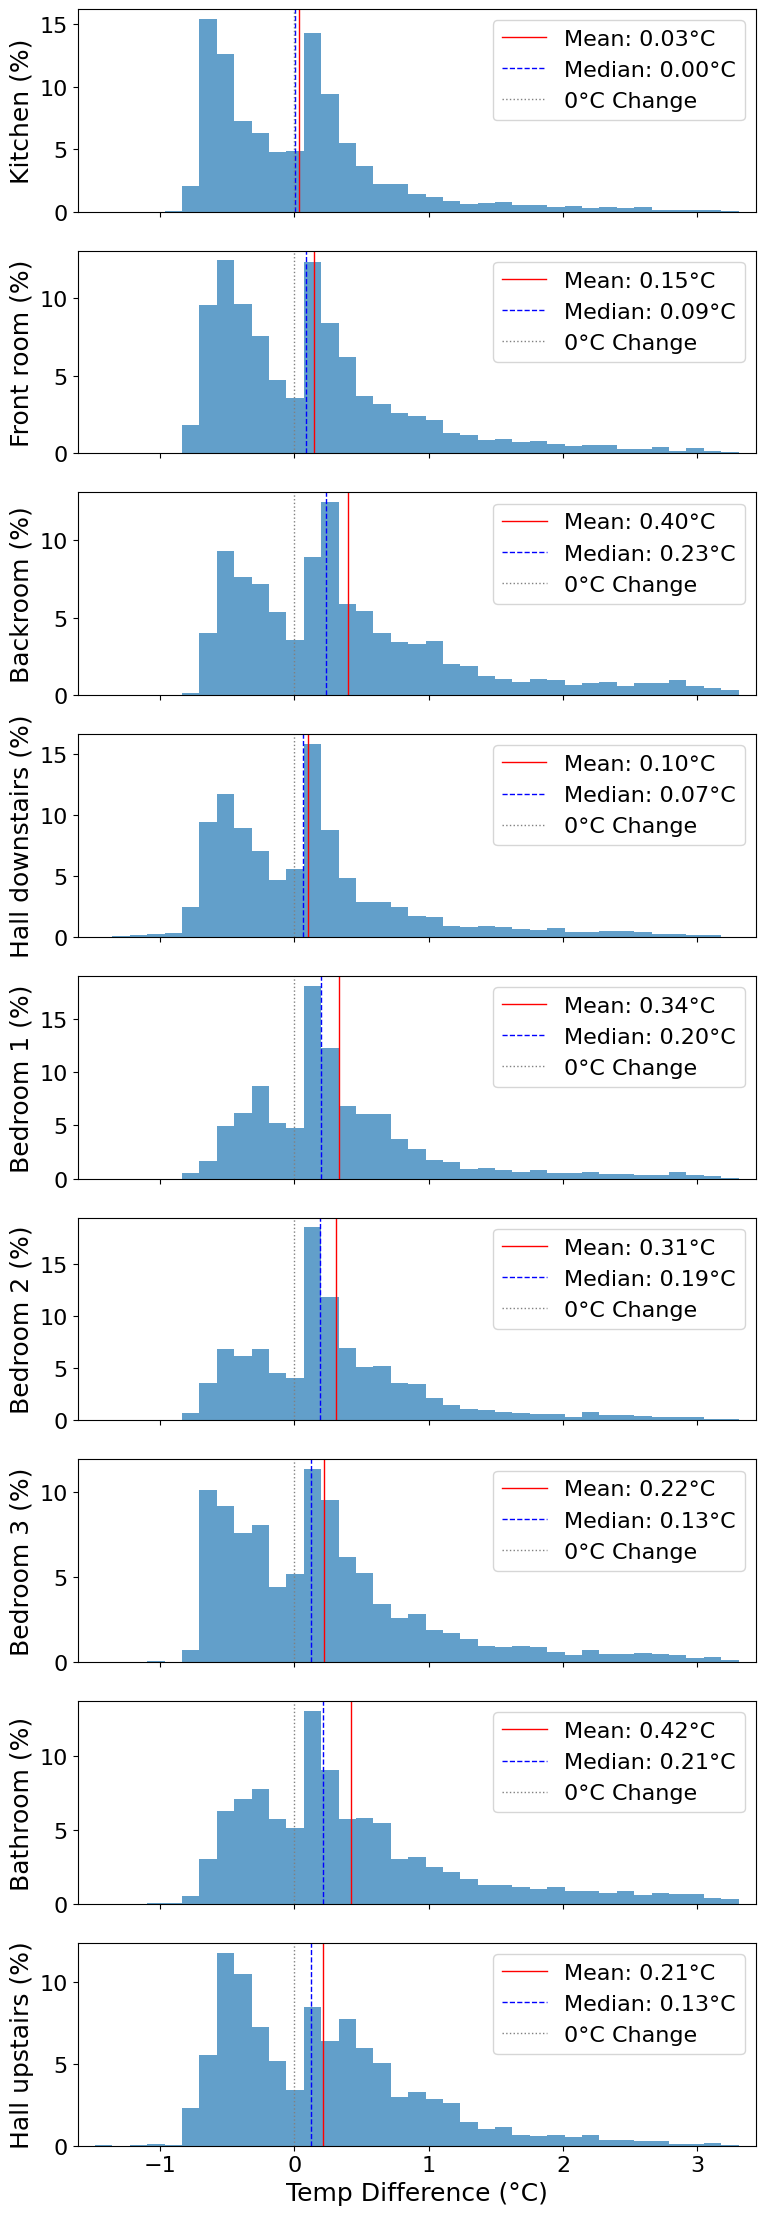

In [17]:

plot_temp_difference_histogram(data, 'Zone 0, Comfort 20.0°C, Threshold 30', 'Zone 9, Comfort 21.0°C, Threshold 15', 'operative', "heating_months")

In [112]:
def plot_temperature_distributions(data_dict, baseline_label, comparison_label, temp_type, period_type):
    periods = {
        'week': ('2013-01-22', '2013-01-29'),
        'heating_months': [('2013-01-01', '2013-04-01'), ('2013-10-01', '2014-01-01')]
    }

    if period_type == 'week':
        start, end = periods['week']
        timed_period = data_dict[baseline_label].loc[start:end].resample('10T').mean()
        not_timed_period = data_dict[comparison_label].loc[start:end].resample('10T').mean()
    elif period_type == 'heating_months':
        timed_period = pd.concat([
            data_dict[baseline_label].loc[start:end].resample('10T').mean()
            for start, end in periods['heating_months']
        ])
        not_timed_period = pd.concat([
            data_dict[comparison_label].loc[start:end].resample('10T').mean()
            for start, end in periods['heating_months']
        ])
    else:
        raise ValueError("Invalid period type. Choose 'week' or 'heating_months'.")

    if temp_type == 'operative':
        temp_columns = {zone: f'Zone Operative Temperature({zone})' for zone in room_areas.keys()}
    elif temp_type == 'air':
        temp_columns = {zone: f'Zone Air Temperature({zone})' for zone in room_areas.keys()}
    else:
        raise ValueError("Invalid temperature type. Choose 'operative' or 'air'.")

    # Calculate room-weighted temperatures for each time period
    timed_weighted_temps = []
    not_timed_weighted_temps = []

    for period, weighted_temps in [(timed_period, timed_weighted_temps), (not_timed_period, not_timed_weighted_temps)]:
        for timestamp in period.index:
            occupied_temps = []
            occupied_areas = []
            for zone, area in room_areas.items():
                occupancy_col = f'Zone People Occupant Count({zone})'
                temp_col = temp_columns[zone]
                if period.at[timestamp, occupancy_col] > 0:
                    occupied_temps.append(period.at[timestamp, temp_col] * area)
                    occupied_areas.append(area)
            if occupied_temps:
                # Calculate the weighted average only for occupied zones at this timestamp
                weighted_temp = sum(occupied_temps) / sum(occupied_areas)
                weighted_temps.append(weighted_temp)

    global_temp_min = min(min(timed_weighted_temps), min(not_timed_weighted_temps))
    global_temp_max = max(max(timed_weighted_temps), max(not_timed_weighted_temps))
    bins = np.linspace(global_temp_min, global_temp_max, 30)

    fig, ax = plt.subplots(figsize=(8, 6))

    baseline_counts, _ = np.histogram(timed_weighted_temps, bins=bins)
    baseline_percentage = baseline_counts / len(timed_weighted_temps) * 100
    ax.bar(bins[:-1], baseline_percentage, width=np.diff(bins), align='edge', color='grey', alpha=0.5, label='Baseline')

    comparison_counts, _ = np.histogram(not_timed_weighted_temps, bins=bins)
    comparison_percentage = comparison_counts / len(not_timed_weighted_temps) * 100
    ax.bar(bins[:-1], comparison_percentage, width=np.diff(bins), align='edge', color='orange', alpha=0.5, label='Comparison')

    baseline_mean = np.mean(timed_weighted_temps)
    baseline_median = np.median(timed_weighted_temps)
    comparison_mean = np.mean(not_timed_weighted_temps)
    comparison_median = np.median(not_timed_weighted_temps)

    # ax.axvline(baseline_mean, color='blue', linestyle='-', linewidth=1)
    # ax.axvline(baseline_median, color='blue', linestyle='--', linewidth=1)
    ax.text(comparison_mean+0.85, ax.get_ylim()[1] * 0.9, f'{baseline_mean:.1f}°C Mean', color='grey', ha='center')
    ax.text(comparison_median-0.5, ax.get_ylim()[1] * 0.9, f'Med. {baseline_median:.1f}', color='grey', ha='center')

    # ax.axvline(comparison_mean, color='orange', linestyle='-', linewidth=1)
    # ax.axvline(comparison_median, color='orange', linestyle='--', linewidth=1)
    ax.text(comparison_mean+0.85, ax.get_ylim()[1] * 0.7, f'{comparison_mean:.1f}°C Mean', color='orange', ha='center')
    ax.text(comparison_median-0.5, ax.get_ylim()[1] * 0.7, f'Med. {comparison_median:.1f}', color='orange', ha='center')

    ax.set_xlabel('Temperature (°C)')
    ax.set_ylabel('Room-weighted Distribution (%)')
    ax.set_xlim(global_temp_min, global_temp_max)
    # ax.legend(loc='upper right', frameon=False)
    plt.tight_layout()
    plt.show()


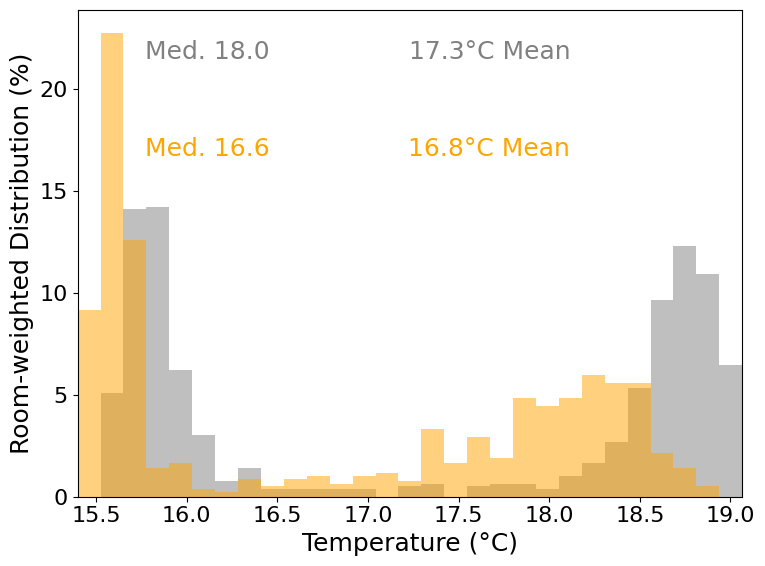

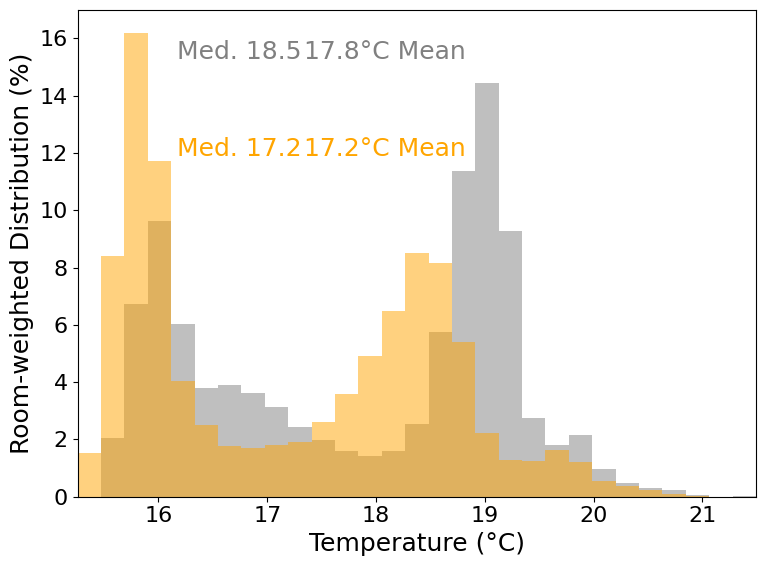

In [113]:
plot_temperature_distributions(data, 'Zone 0, Comfort 20.0°C, Threshold 30', 'Zone 9, Comfort 20.0°C, Threshold 15', 'operative', "week")
plot_temperature_distributions(data, 'Zone 0, Comfort 20.0°C, Threshold 30', 'Zone 9, Comfort 20.0°C, Threshold 15', 'operative', "heating_months")

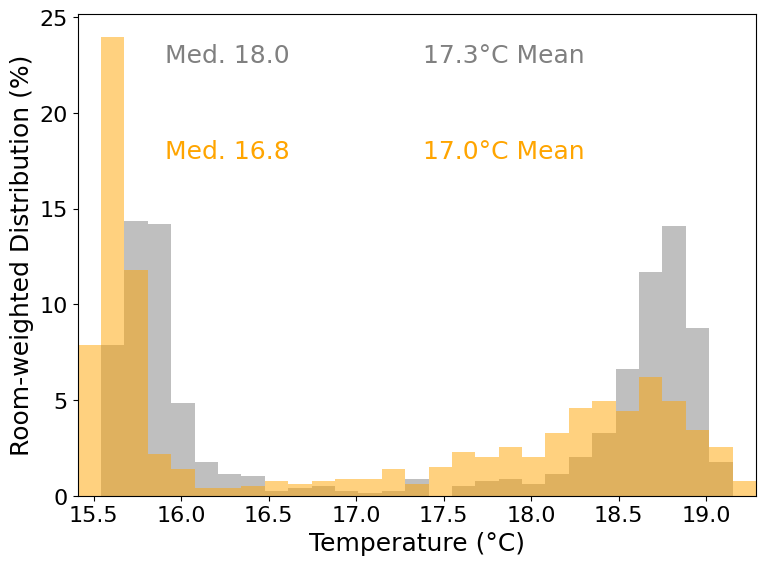

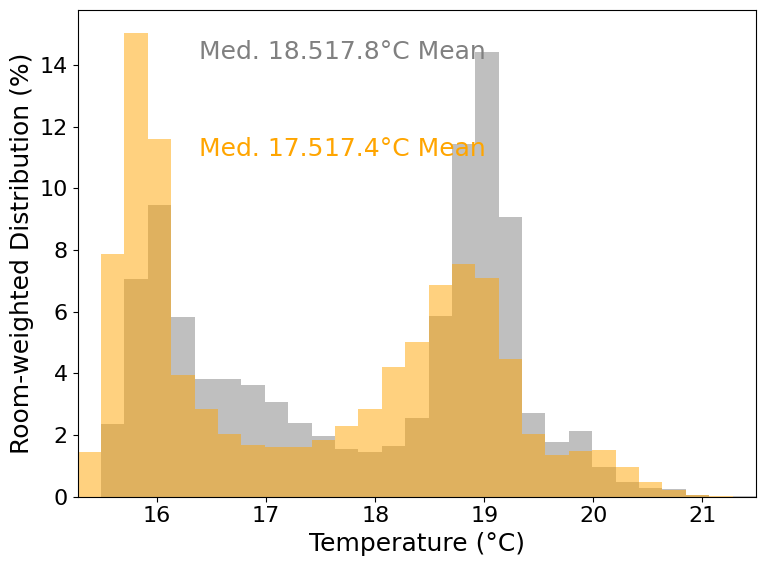

In [114]:
plot_temperature_distributions(data, 'Zone 0, Comfort 20.0°C, Threshold 30', 'Zone 9, Comfort 20.5°C, Threshold 15', 'operative', "week")
plot_temperature_distributions(data, 'Zone 0, Comfort 20.0°C, Threshold 30', 'Zone 9, Comfort 20.5°C, Threshold 15', 'operative', "heating_months")

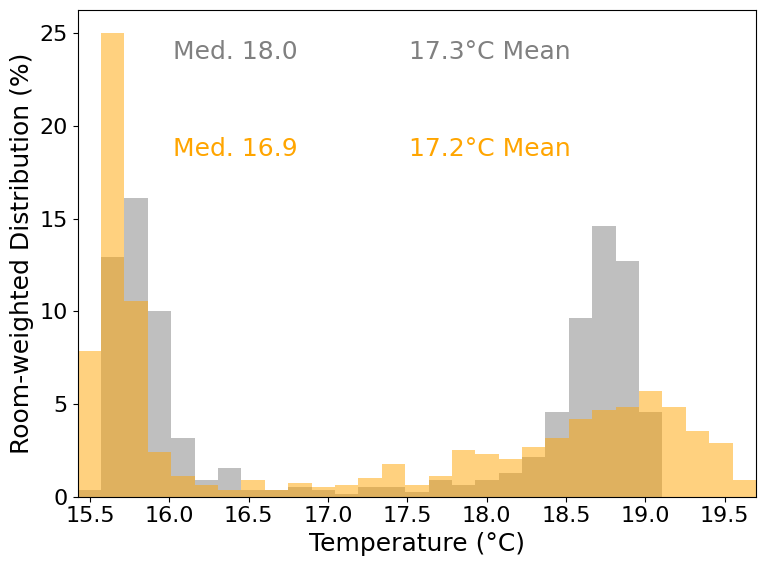

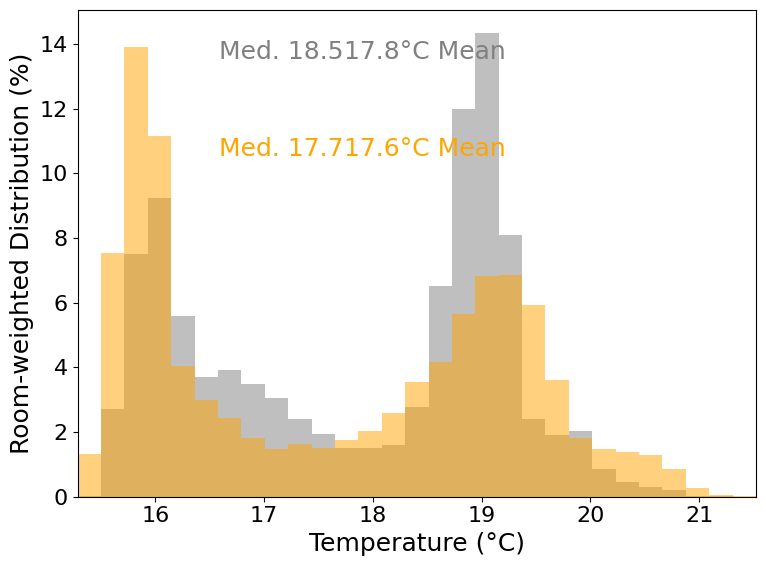

In [115]:
plot_temperature_distributions(data, 'Zone 0, Comfort 20.0°C, Threshold 30', 'Zone 9, Comfort 21.0°C, Threshold 15', 'operative', "week")
plot_temperature_distributions(data, 'Zone 0, Comfort 20.0°C, Threshold 30', 'Zone 9, Comfort 21.0°C, Threshold 15', 'operative', "heating_months")

In [ ]:
def plot_temperature_distributions(data_dict, baseline_label, comparison_label, temp_type, period_type):
    periods = {
        'week': ('2013-01-22', '2013-01-29'),
        'heating_months': [('2013-01-01', '2013-04-01'), ('2013-10-01', '2014-01-01')]
    }

    if period_type == 'week':
        start, end = periods['week']
        timed_period = data_dict[baseline_label].loc[start:end].resample('10T').mean()
        not_timed_period = data_dict[comparison_label].loc[start:end].resample('10T').mean()
    elif period_type == 'heating_months':
        timed_period = pd.concat([
            data_dict[baseline_label].loc[start:end].resample('10T').mean()
            for start, end in periods['heating_months']
        ])
        not_timed_period = pd.concat([
            data_dict[comparison_label].loc[start:end].resample('10T').mean()
            for start, end in periods['heating_months']
        ])
    else:
        raise ValueError("Invalid period type. Choose 'week' or 'heating_months'.")

    num_zones_to_show = 9

    if temp_type == 'operative':
        temp_columns = {zone: f'Zone Operative Temperature({zone})' for zone in room_areas.keys()}
    elif temp_type == 'air':
        temp_columns = {zone: f'Zone Air Temperature({zone})' for zone in room_areas.keys()}
    else:
        raise ValueError("Invalid temperature type. Choose 'operative' or 'air'.")

    fig, axes = plt.subplots(num_zones_to_show, 1, figsize=(8, 2.5 * num_zones_to_show), sharex=True)
    global_temp_min, global_temp_max = float('inf'), float('-inf')

    for zone in list(room_areas.keys())[:num_zones_to_show]:
        temp_column = temp_columns[zone]
        global_temp_min = min(global_temp_min, timed_period[temp_column].min(), not_timed_period[temp_column].min())
        global_temp_max = max(global_temp_max, timed_period[temp_column].max(), not_timed_period[temp_column].max())

    for i, zone in enumerate(list(room_areas.keys())[:num_zones_to_show]):
        ax = axes[i]
        temp_column = temp_columns[zone]
        occupancy_column = f'Zone People Occupant Count({zone})'

        baseline_temps = timed_period[temp_column][timed_period[occupancy_column] > 0].dropna()
        baseline_bins = np.linspace(global_temp_min, global_temp_max, 30)
        baseline_counts, _ = np.histogram(baseline_temps, bins=baseline_bins)
        baseline_percentage = baseline_counts / len(baseline_temps) * 100
        ax.bar(baseline_bins[:-1], baseline_percentage, width=np.diff(baseline_bins), align='edge', color='grey', alpha=0.5, label='Baseline')

        comparison_temps = not_timed_period[temp_column][not_timed_period[occupancy_column] > 0].dropna()
        comparison_counts, _ = np.histogram(comparison_temps, bins=baseline_bins)
        comparison_percentage = comparison_counts / len(comparison_temps) * 100
        ax.bar(baseline_bins[:-1], comparison_percentage, width=np.diff(baseline_bins), align='edge', color='orange', alpha=0.5, label='Comparison')

        baseline_mean = baseline_temps.mean()
        baseline_median = baseline_temps.median()
        # ax.axvline(baseline_mean, color='blue', linestyle='-', linewidth=1)
        # ax.axvline(baseline_median, color='blue', linestyle='--', linewidth=1)
        ax.text(ax.get_xlim()[1]-1, ax.get_ylim()[1] * 0.9, f'Mean {baseline_mean:.1f}°C', color='blue', ha='center', va='center', fontsize=10)
        ax.text(ax.get_xlim()[1]-2, ax.get_ylim()[1] * 0.9, f'Med. {baseline_median:.1f}°C', color='blue', ha='center', va='center', fontsize=10)

        comparison_mean = comparison_temps.mean()
        comparison_median = comparison_temps.median()
        # ax.axvline(comparison_mean, color='orange', linestyle='-', linewidth=1)
        # ax.axvline(comparison_median, color='orange', linestyle='--', linewidth=1)
        ax.text(ax.get_xlim()[1]-1, ax.get_ylim()[1] * 0.7, f'Mean {comparison_mean:.1f}°C', color='orange', ha='center', va='center', fontsize=10)
        ax.text(ax.get_xlim()[1]-2, ax.get_ylim()[1] * 0.7, f'Med. {comparison_median:.1f}°C', color='orange', ha='center', va='center', fontsize=10)

        diff_mean = comparison_mean - baseline_mean
        diff_median = comparison_median - baseline_median

        ax.text(ax.get_xlim()[1]-1, ax.get_ylim()[1] * 0.5, f'{diff_mean:.1f}°C', color='black', ha='center', va='center', fontsize=10)
        ax.text(ax.get_xlim()[1]-2, ax.get_ylim()[1] * 0.5, f'{diff_median:.1f}°C', color='black', ha='center', va='center', fontsize=10)

        ax.set_ylabel(f'{zone.replace("_", " ").capitalize()} (%)')
        ax.set_xlim(global_temp_min, global_temp_max)

    axes[-1].set_xlabel('Temperature (°C)')
    plt.tight_layout()
    plt.show()


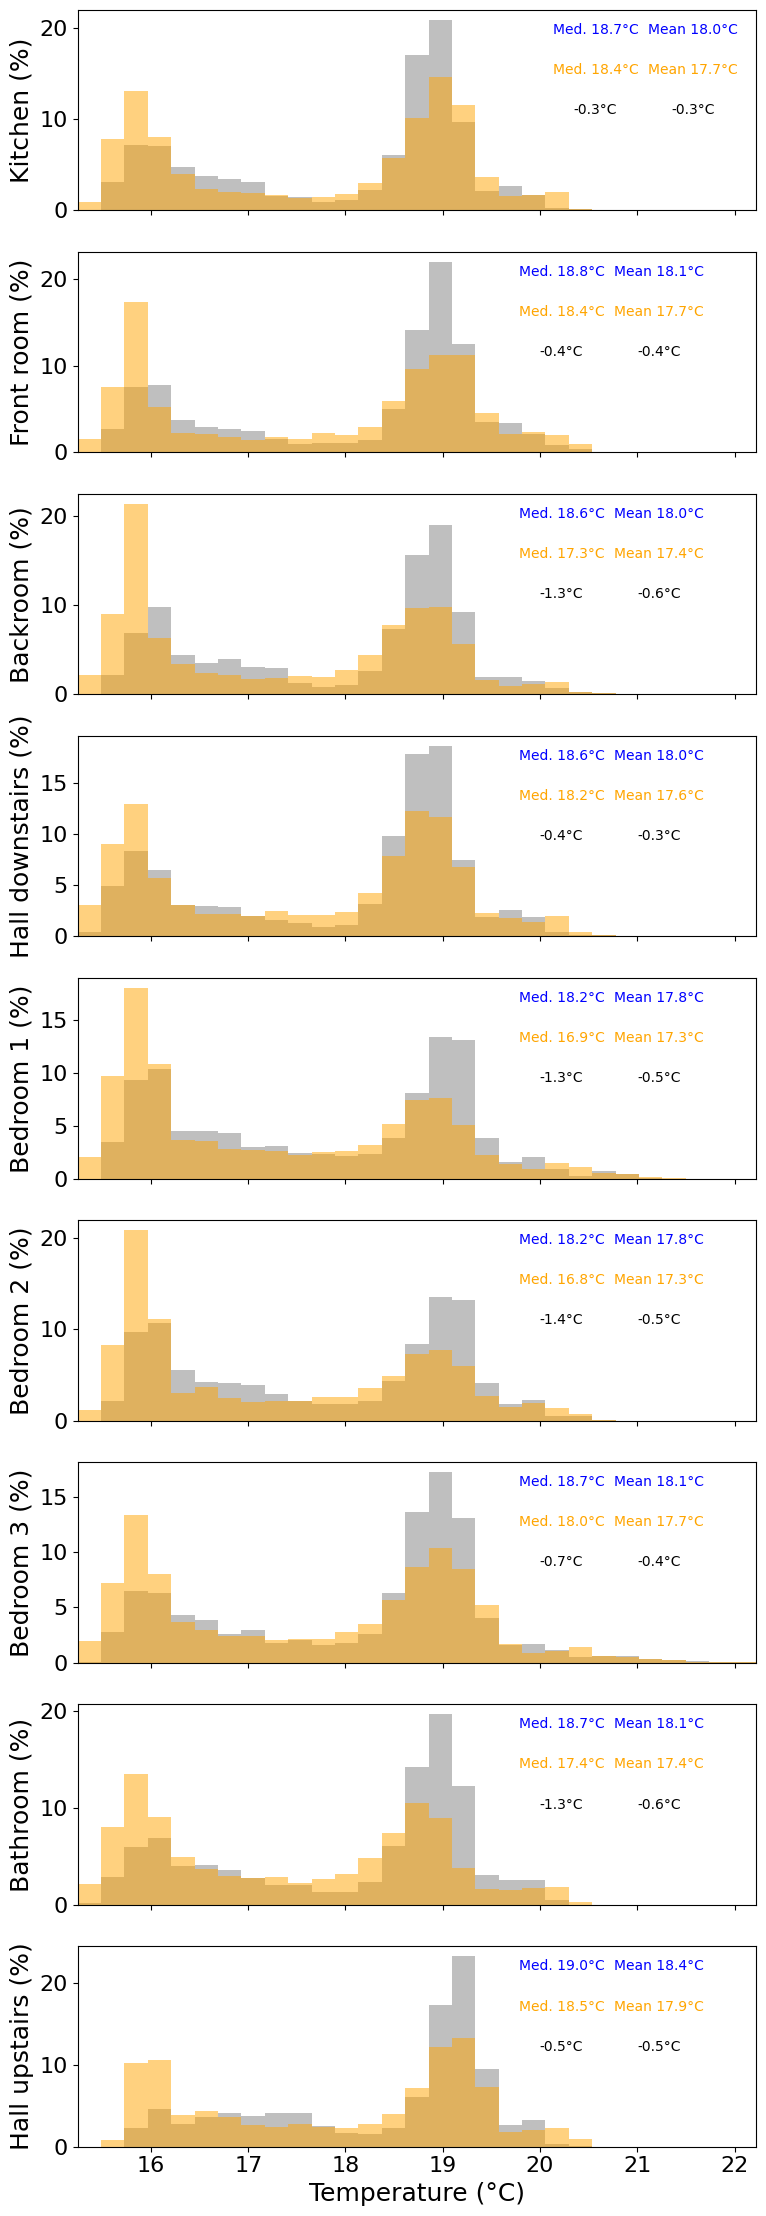

In [50]:
plot_temperature_distributions(data, 'Zone 0, Comfort 20.0°C, Threshold 30', 'Zone 9, Comfort 20.5°C, Threshold 15', 'operative', "heating_months")

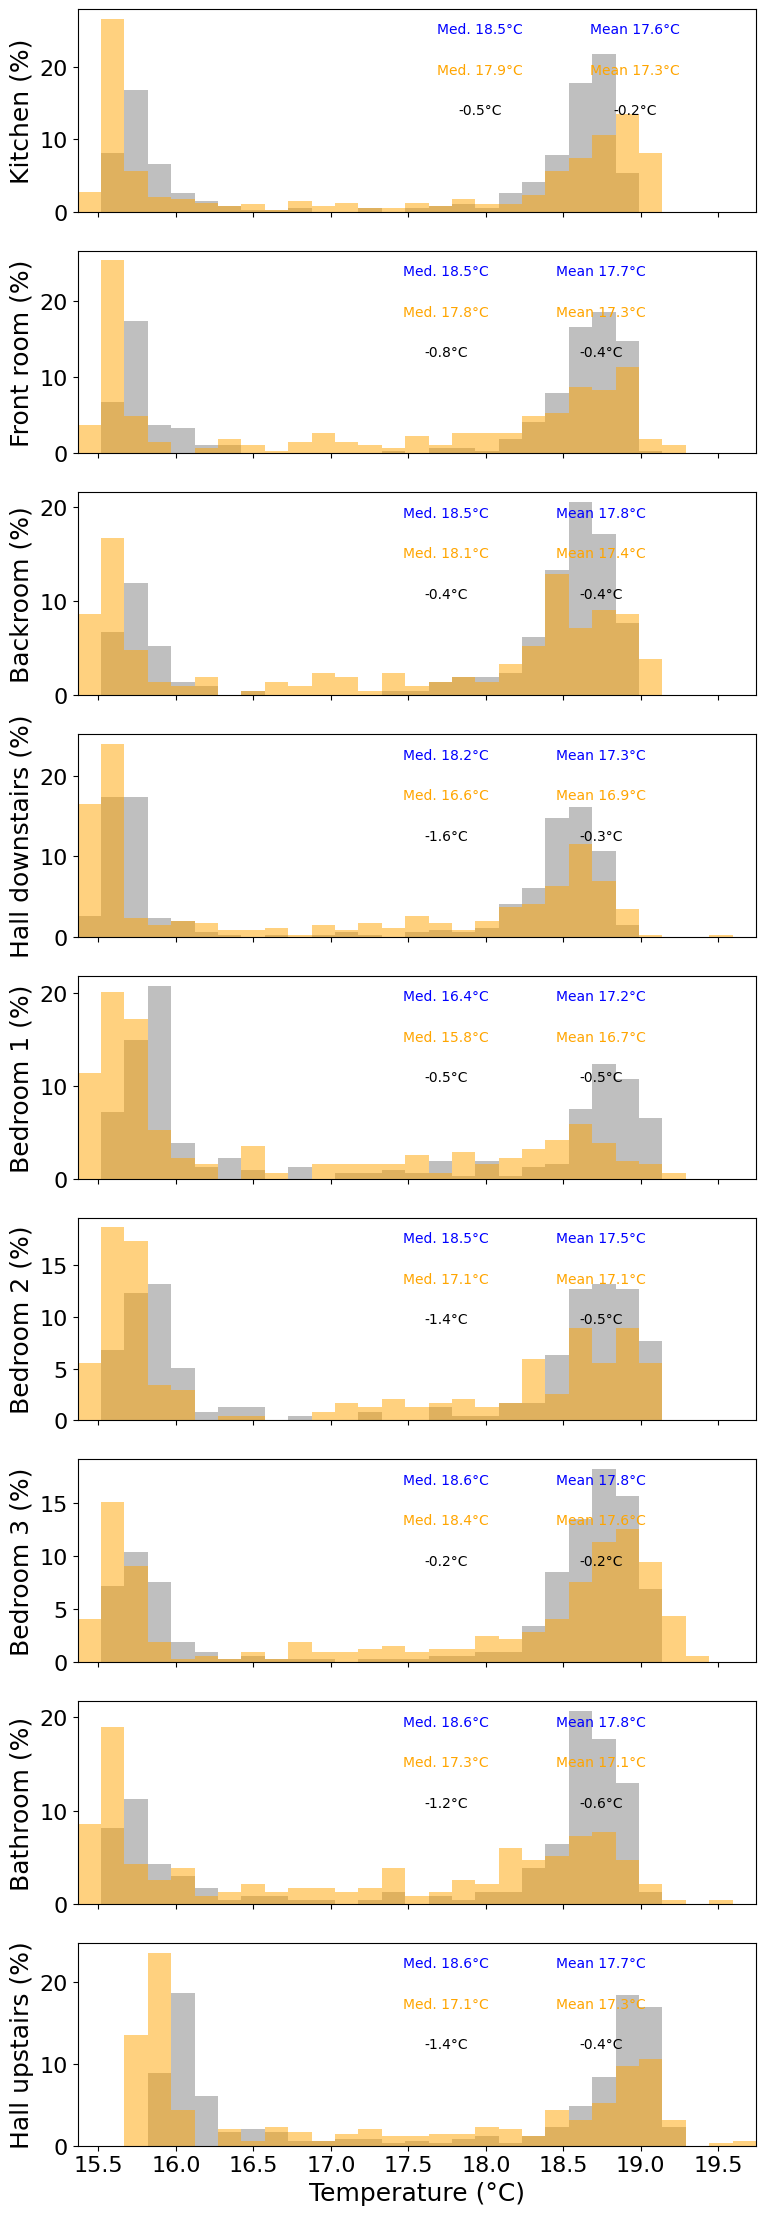

In [49]:
plot_temperature_distributions(data, 'Zone 0, Comfort 20.0°C, Threshold 30', 'Zone 9, Comfort 20.5°C, Threshold 15', 'operative', "week")

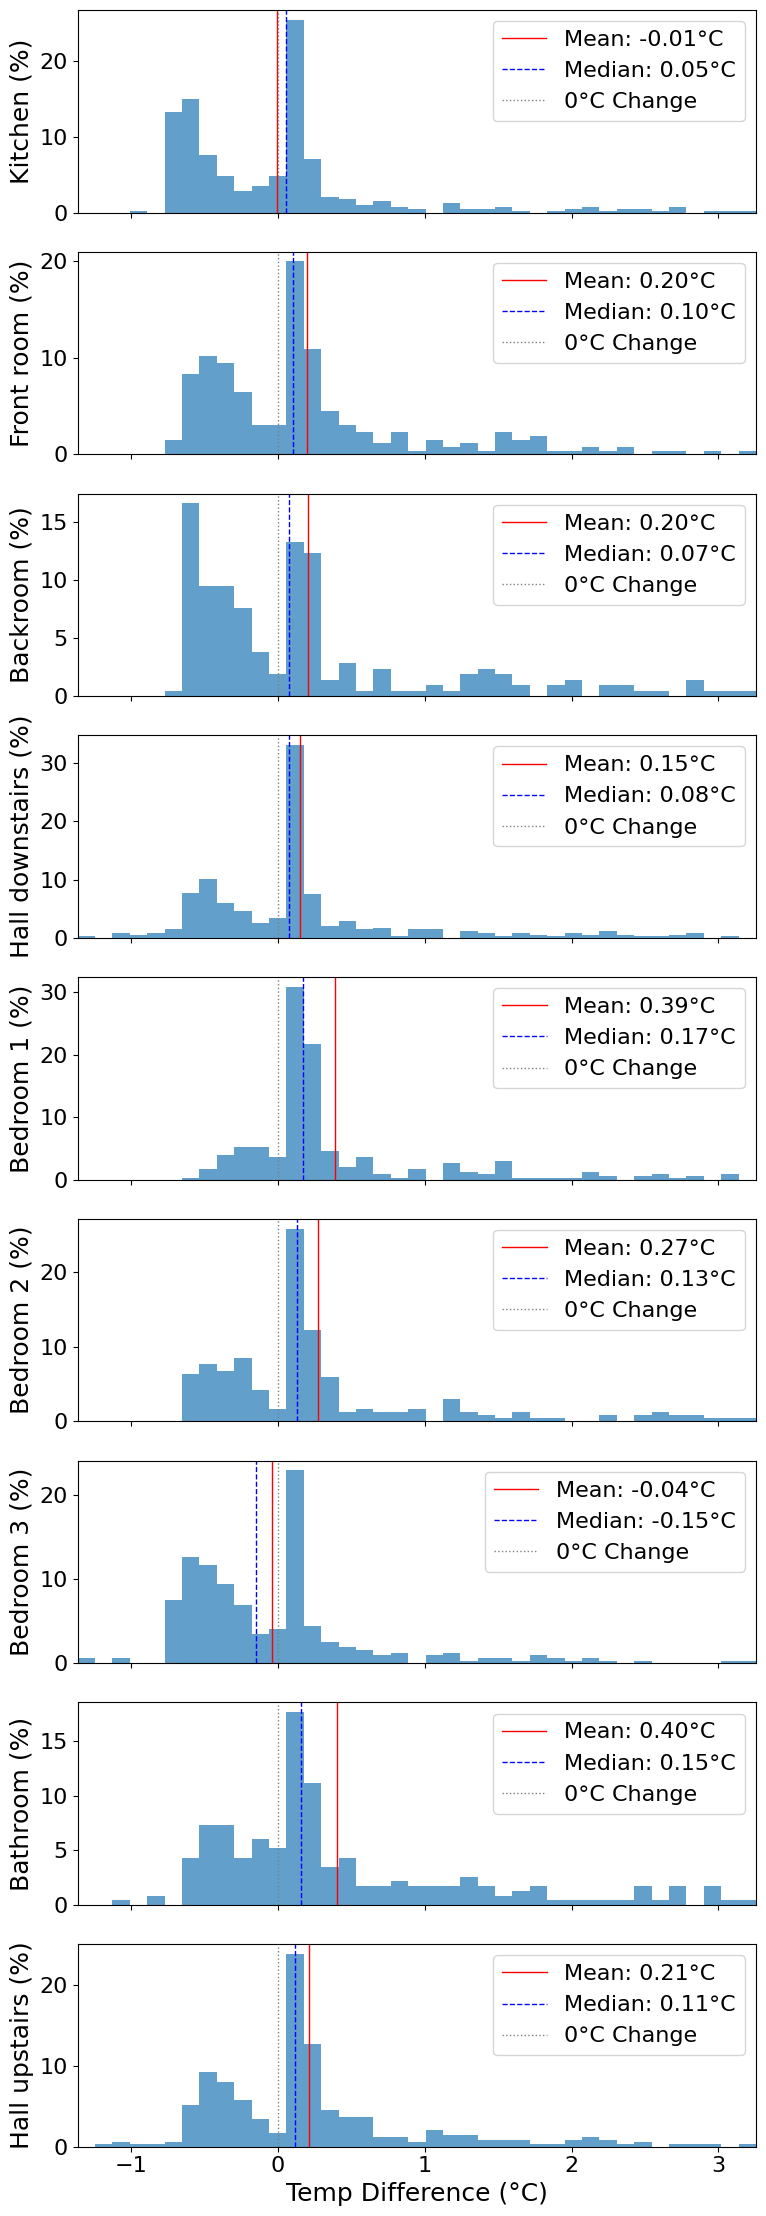

In [12]:
plot_temp_difference_histogram(data, 'Zone 0, Comfort 20.0°C, Threshold 30', 'Zone 9, Comfort 21.0°C, Threshold 15', 'operative')

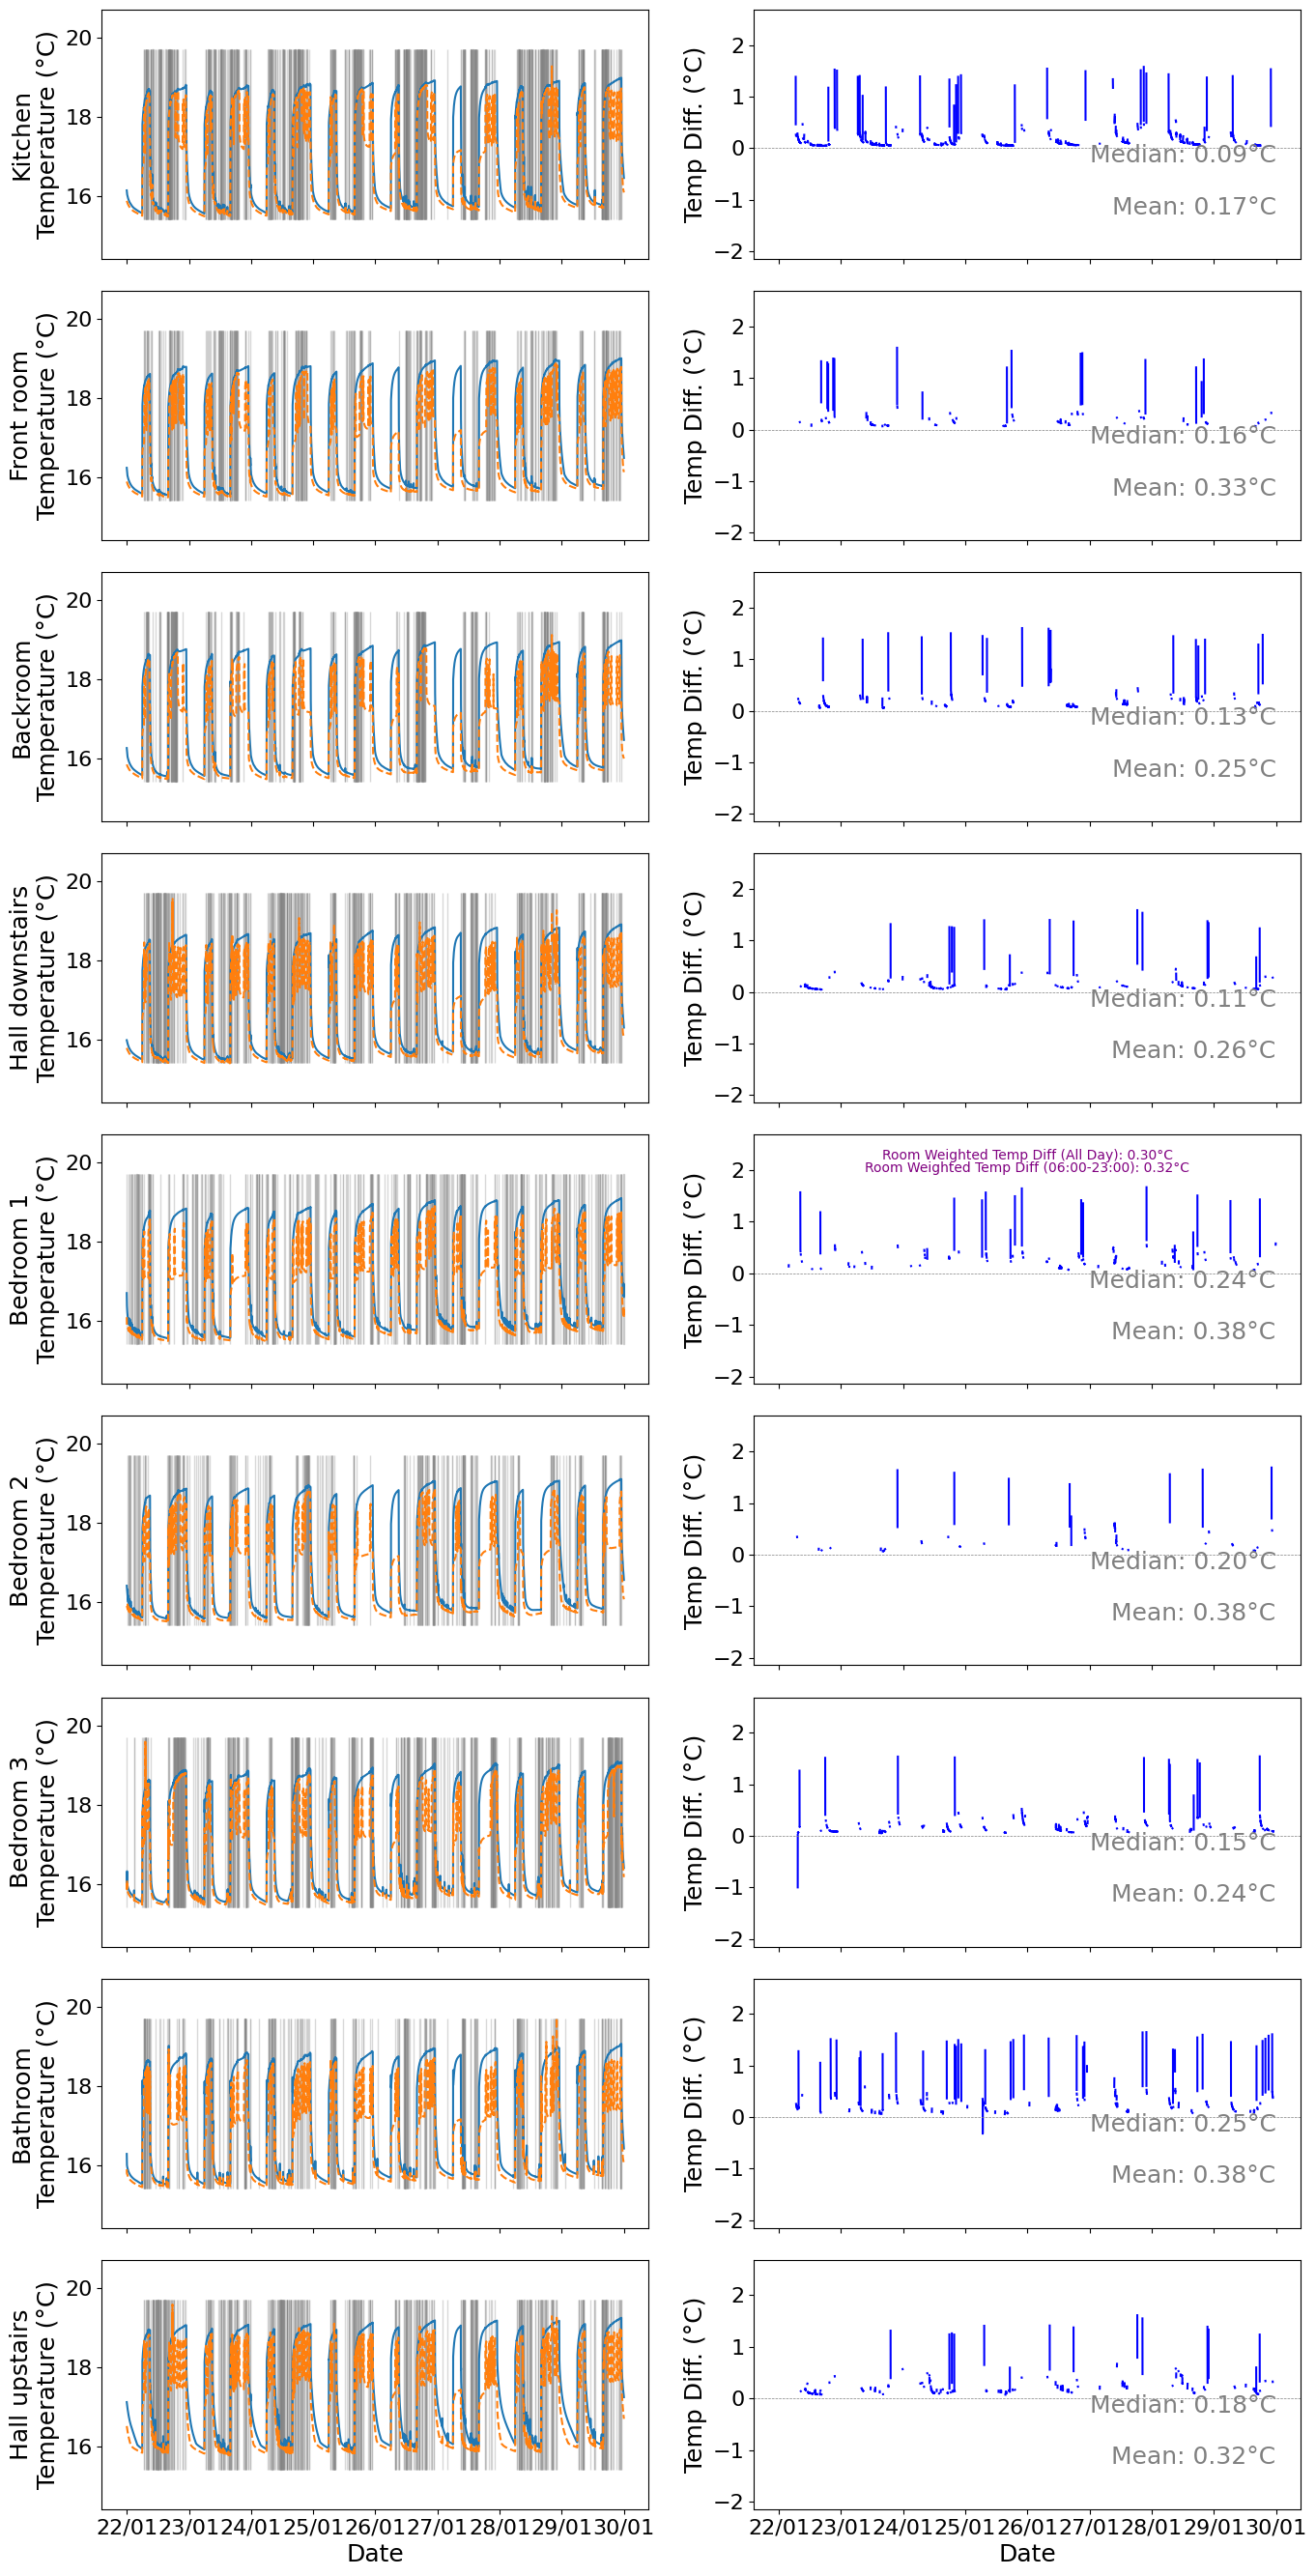

In [21]:
plot_temp_comparison(data, 'Zone 0, Comfort 20.0°C, Threshold 30', 'Zone 9, Comfort 20.0°C, Threshold 15', 'operative')


In [4]:

# Load data and set UTC_Time as index
baseline = pd.read_csv(
    "/workspaces/CUBES/exp/jack/paper/thermostat_experiment/SI/fixed_occ_check/files/Eplus-env-11-09_thermostat_rbc_eco_year_2023_case_0_rep_H28_zone_0_inactive_threshold_30_comforttemp_20.0_setbacktemp_16.0_pattern_twice_timesteps_60_longer_heating_check_v3-res1_condensed.csv.xz",
    parse_dates=["UTC_Time"]
)
baseline.set_index("UTC_Time", inplace=True)


file_path = "/workspaces/CUBES/exp/jack/paper/thermostat_experiment/SI/fixed_occ_check/files/Eplus-env-11-09_thermostat_rbc_eco_year_2023_case_0_rep_H28_zone_9_inactive_threshold_15_comforttemp_20.5_setbacktemp_16.0_pattern_twice_timesteps_60_longer_heating_check_v3-res1_condensed.csv.xz"

# Step 1: Load column names
columns = pd.read_csv(file_path, nrows=0).columns.tolist()

# Step 2: Set data types (UTC_Time as date, others as float)
dtypes = {col: "float" for col in columns if col != "UTC_Time"}

# Step 3: Read file with specified dtypes and parse_dates for UTC_Time
comp = pd.read_csv(file_path, parse_dates=["UTC_Time"], dtype=dtypes)
comp.set_index("UTC_Time", inplace=True)




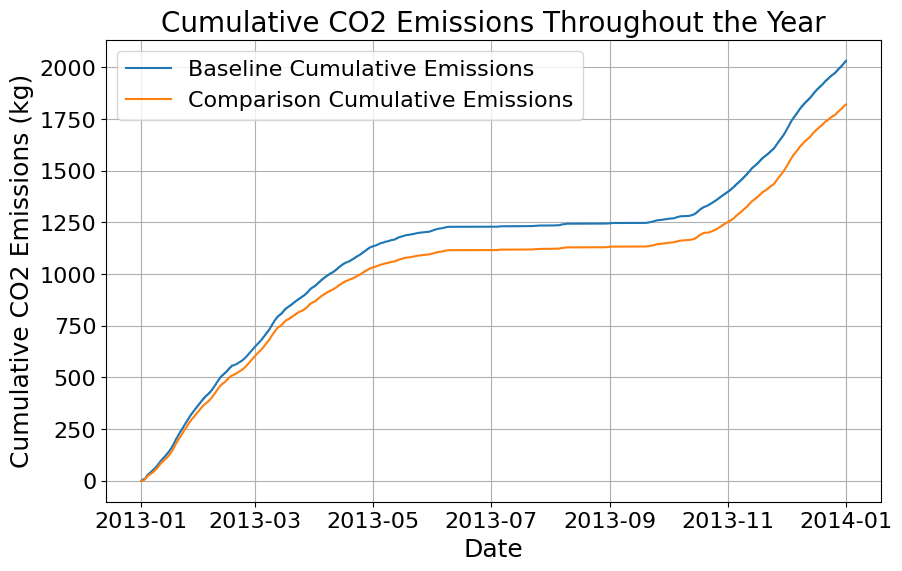

In [5]:


emissions_col = 'Environmental Impact Total CO2 Emissions Carbon Equivalent Mass(Site)'

baseline_cumulative = baseline[emissions_col].cumsum()
comp_cumulative = comp[emissions_col].cumsum()

plt.figure(figsize=(10, 6))
plt.plot(baseline.index, baseline_cumulative, label='Baseline Cumulative Emissions')
plt.plot(comp.index, comp_cumulative, label='Comparison Cumulative Emissions')
plt.xlabel('Date')
plt.ylabel('Cumulative CO2 Emissions (kg)')
plt.title('Cumulative CO2 Emissions Throughout the Year')
plt.legend()
plt.grid()
plt.show()


In [6]:
baseline['Environmental Impact Total CO2 Emissions Carbon Equivalent Mass(Site)'].sum()

2032.6238390366248